# 01 — Analyse exploratoire du corpus

KOMOSSI Sosso — Master BIG DATA IA, Institut ESI — UCAO-UUT, 2025-2026

Reconstruit après l'incident disque du 26/08/2026 (voir `README.md`, section « Incident du 26/08/2026 et reprise »). Toutes les valeurs de ce notebook sont lues depuis `data/processed/preprocessing_report.json`, produit par `scripts/preprocess_data.py` — aucune valeur n'est recalculée ni inventée ici.

In [1]:
import json, os
import pandas as pd
import matplotlib.pyplot as plt

ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
with open(os.path.join(ROOT, 'data/processed/preprocessing_report.json')) as f:
    report = json.load(f)
report

{'total_before_dedup': 174059,
 'total_after_dedup': 77768,
 'duplicates_removed': 96291,
 'n_train': 46660,
 'n_val': 15554,
 'n_test': 15554,
 'sources': {'welfake': 44609,
  'fakenewsnet': 13350,
  'liar': 9247,
  'masakhanews_hau': 1580,
  'masakhanews_swa': 1177,
  'masakhanews_yor': 985,
  'masakhanews_sna': 917,
  'masakhanews_ibo': 898,
  'masakhanews_amh': 834,
  'masakhanews_orm': 794,
  'masakhanews_run': 792,
  'masakhanews_pcm': 729,
  'masakhanews_som': 722,
  'masakhanews_tir': 640,
  'masakhanews_lin': 398,
  'google_news_africa_rss': 96}}

## Volume du corpus : avant / après déduplication

Les 4 datasets classiques (ISOT, WELFake, FakeNewsNet, LIAR) et le sous-corpus africain (MasakhaNEWS + Google News RSS Afrique) sont agrégés puis dédupliqués sur le titre. ISOT est entièrement absorbé par WELFake (recoupement Reuters + sites fake déjà présents) : il ne contribue à aucun exemple unique du corpus final.

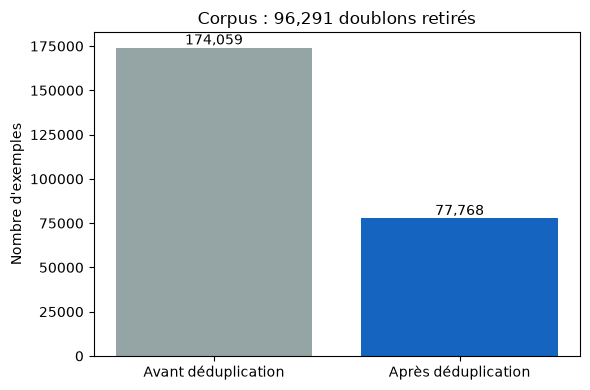

In [2]:
fig, ax = plt.subplots(figsize=(6, 4))
vals = [report['total_before_dedup'], report['total_after_dedup']]
labels = ['Avant déduplication', 'Après déduplication']
bars = ax.bar(labels, vals, color=['#95A5A6', '#1565C0'])
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v, f'{v:,}', ha='center', va='bottom')
ax.set_ylabel("Nombre d'exemples")
ax.set_title(f"Corpus : {report['duplicates_removed']:,} doublons retirés")
plt.tight_layout(); plt.show()

## Composition par source (corpus final, après déduplication et équilibrage)

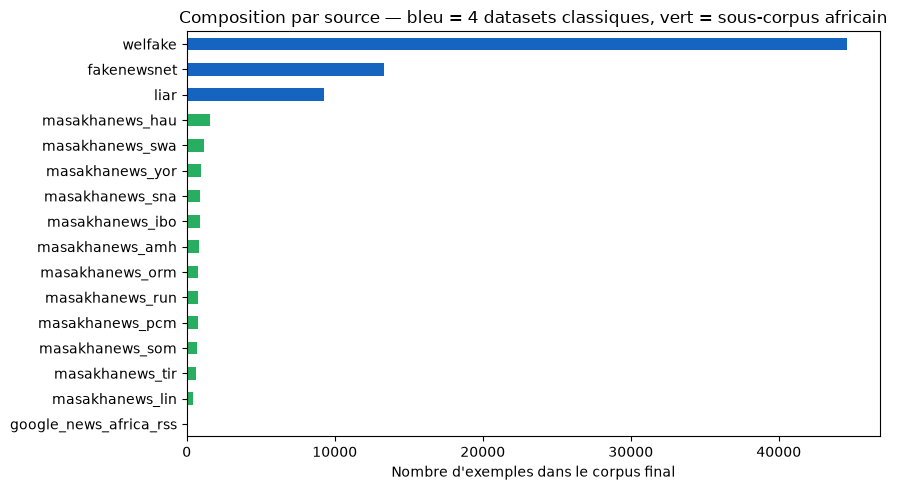

welfake                   44609
fakenewsnet               13350
liar                       9247
masakhanews_hau            1580
masakhanews_swa            1177
masakhanews_yor             985
masakhanews_sna             917
masakhanews_ibo             898
masakhanews_amh             834
masakhanews_orm             794
masakhanews_run             792
masakhanews_pcm             729
masakhanews_som             722
masakhanews_tir             640
masakhanews_lin             398
google_news_africa_rss       96
dtype: int64

In [3]:
sources = pd.Series(report['sources']).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#1565C0' if not s.startswith('masakhanews') and s != 'google_news_africa_rss'
          else '#27AE60' for s in sources.index]
sources.plot(kind='barh', ax=ax, color=colors)
ax.invert_yaxis()
ax.set_xlabel("Nombre d'exemples dans le corpus final")
ax.set_title('Composition par source — bleu = 4 datasets classiques, vert = sous-corpus africain')
plt.tight_layout(); plt.show()
sources

**Lecture** : WELFake domine le corpus (44 609 exemples). Le sous-corpus africain (MasakhaNEWS, 12 langues, + Google News RSS Afrique) totalise 10 562 exemples répartis sur 13 sources, chacune ne représentant que quelques centaines d'exemples malgré le facteur de sur-pondération `--africa_boost` (×5) appliqué à l'entraînement. Ce déséquilibre structurel — déjà documenté au chapitre 3 du mémoire — explique en partie la performance hétérogène du modèle par source (cf. notebook `02_error_analysis.ipynb`).

## Split train / val / test

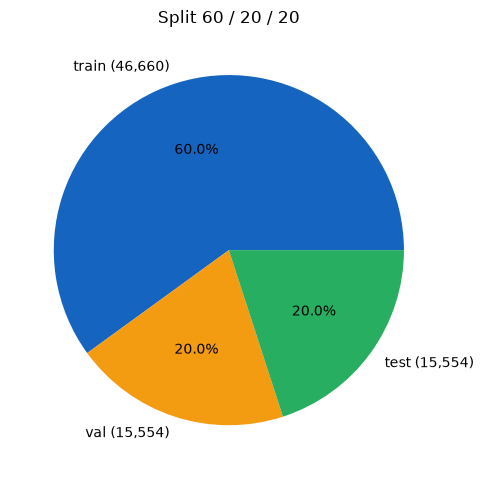

In [4]:
split = pd.Series({'train': report['n_train'], 'val': report['n_val'], 'test': report['n_test']})
fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(split, labels=[f'{k} ({v:,})' for k, v in split.items()], autopct='%1.1f%%',
       colors=['#1565C0', '#F39C12', '#27AE60'])
ax.set_title('Split 60 / 20 / 20')
plt.tight_layout(); plt.show()

## Longueur des textes et langues détectées

Cette section nécessite les fichiers `data/raw/*` (non versionnés — voir `.gitignore` — et téléchargeables via `scripts/download_datasets.sh` + `scripts/download_african_datasets.py`). Elle est fournie ici pour reproduction locale ; elle est ignorée silencieusement si les fichiers bruts sont absents (cas du dépôt Git, qui ne contient pas les données brutes pour des raisons de taille).

In [5]:
import glob
raw_files = glob.glob(os.path.join(ROOT, 'data/raw/**/*.csv'), recursive=True)
if raw_files:
    frames = []
    for fp in raw_files[:20]:
        try:
            d = pd.read_csv(fp, usecols=lambda c: c.lower() in ('title', 'body', 'text'), nrows=5000)
            frames.append(d)
        except Exception:
            pass
    print(f'{len(raw_files)} fichiers bruts trouvés, {len(frames)} échantillonnés.')
else:
    print('data/raw/ absent de ce checkout — voir scripts/download_datasets.sh '
          'et scripts/download_african_datasets.py pour reconstituer les données brutes.')

8 fichiers bruts trouvés, 8 échantillonnés.
